# Test

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from algorithms.ale_vim import generate_connected_paths, ale_connected_total, ale_global_main, ale_quantile_total
from algorithms.ale import bin_selection, ale_1d

In [2]:
def generate_2d_data_normal(n, rho=0.5):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_2d_data_uniform(n, sigma=0.5):
    x1 = np.random.uniform(-np.sqrt(2), np.sqrt(2), n)
    x2 = x1 + np.random.multivariate_normal([0], [[sigma]], n).flatten()
    return np.column_stack((x1, x2))

def generate_3d_data_normal(n, rho=0.5):
    mean = [0, 0, 0]
    cov = [[1, rho, rho], [rho, 1, rho], [rho, rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_3d_data_uniform(n, sigma=0.5):
    x1 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    x2 = x1 + np.random.multivariate_normal([0], [[sigma]], n).flatten()
    x3 = x1 + np.random.multivariate_normal([0], [[sigma]], n).flatten()
    return np.column_stack((x1, x2, x3))

def f(x):
    return x[:, 0] + x[:, 1] + x[:, 0] * x[:, 1]

# Generate data
n = 16
X = generate_3d_data_normal(n, rho=0)
y = f(X)

Text(0.5, 0, 'X3')

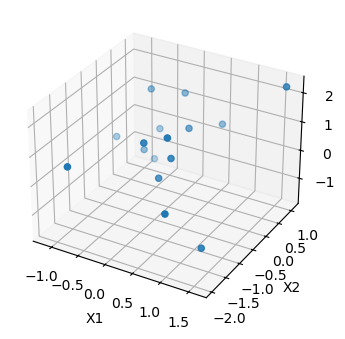

In [3]:
# 3d scatter plot
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2])
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")

Text(0, 0.5, 'X3')

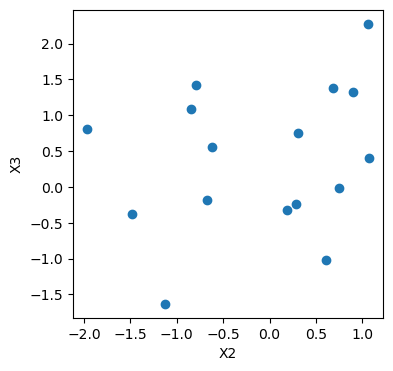

In [4]:
# 2d scatter plot on X_{-j} (excluding the j-th feature)
fig = plt.figure(figsize=(4, 4))
plt.scatter(X[:, 1], X[:, 2])
plt.xlabel("X2")
plt.ylabel("X3")

In [5]:
K = bin_selection(n)
L = n // K
feature_idx = 1
x = X[:, feature_idx - 1]  # Select the feature for ALE
edges = np.quantile(x, np.linspace(0, 1, K + 1))
edges[0], edges[-1] = x.min(), x.max() + np.finfo(np.float16).eps # ensure min/max
# reshape X into (K, L, d)
reshaped_X = np.zeros((K, L, X.shape[1]))
for i in range(K):
    reshaped_X[i] = X[(x >= edges[i]) & (x < edges[i + 1])][:L]

paths = generate_connected_paths(f, reshaped_X, feature_idx, edges)

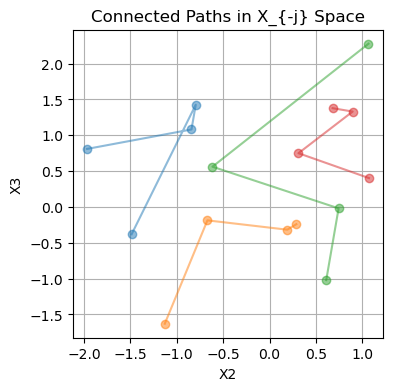

In [6]:
# for each path, plot the path in X_{-j} space
plt.figure(figsize=(4, 4))
for path in paths:
    # each path is (K, d) array, convert to (K, d-1) by removing feature_idx
    path_X = np.delete(path, feature_idx - 1, axis=1)
    plt.plot(path_X[:, 0], path_X[:, 1], marker='o', linestyle='-', alpha=0.5)
plt.xlabel('X2')
plt.ylabel('X3')
plt.title('Connected Paths in X_{-j} Space')
plt.grid()
plt.show()

In [7]:
n_vec = np.array([100, 200, 500, 1000, 2000, 5000, 10000])
replications = 10
ale_connected_total_vals = np.zeros((len(n_vec), replications))
ale_global_main_vals = np.zeros((len(n_vec), replications))
ale_quantile_total_vals = np.zeros((len(n_vec), replications))
rho = 0.5

def custom_bin_selection(n):
    return int(np.sqrt(n))  # Custom bin selection function

for i, n in enumerate(n_vec):
    print(f"Sample size: {n}")
    for r in range(replications):
        X = generate_2d_data_uniform(n, sigma=0.5)
        y = f(X)
        f_lambda = lambda x: f(x)
        K = bin_selection(n)
        feature_idx = 1
        ale_connected_total_vals[i, r] = ale_connected_total(f, X, feature_idx, bins=K)
        ale_global_main_vals[i, r] = ale_global_main(f, X, feature_idx, bins=K)
        ale_quantile_total_vals[i, r] = ale_quantile_total(f_lambda, X, feature_idx, bins=K)

# plot mean and std of ale_connected_total_vals and ale_global_main_vals
mean_connected = np.mean(ale_connected_total_vals, axis=1)
std_connected = np.std(ale_connected_total_vals, axis=1)
mean_global = np.mean(ale_global_main_vals, axis=1)
std_global = np.std(ale_global_main_vals, axis=1)
mean_quantile = np.mean(ale_quantile_total_vals, axis=1)
std_quantile = np.std(ale_quantile_total_vals, axis=1)

Sample size: 100
Sample size: 200
Sample size: 500
Sample size: 1000
Sample size: 2000
Sample size: 5000
Sample size: 10000


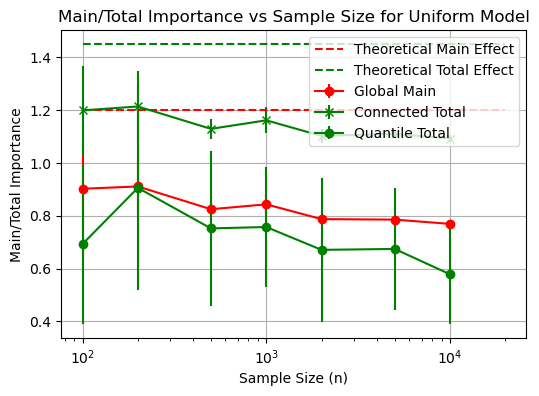

In [8]:
plt.figure(figsize=(6, 4))
# use line plot with errors on the line
plt.errorbar(n_vec, mean_global, yerr=std_global, label='Global Main', marker='o', color='r')
plt.errorbar(n_vec, mean_connected, yerr=std_connected, label='Connected Total', marker='x', color='g')
plt.errorbar(n_vec, mean_quantile, yerr=std_quantile, label='Quantile Total', marker='o', color='g')
# main effect theoretical horizontal line at 6/5
plt.hlines(y=6/5, xmin=np.min(n_vec), xmax=2*np.max(n_vec), color='r', linestyle='--', label='Theoretical Main Effect')
# total effect theoretical horizontal line at 6/5 + rho ** 2
plt.hlines(y=6/5 + (rho ** 2), xmin=np.min(n_vec), xmax=2*np.max(n_vec), color='g', linestyle='--', label='Theoretical Total Effect')
plt.xscale('log')
plt.xlabel('Sample Size (n)')
plt.ylabel('Main/Total Importance')
plt.title('Main/Total Importance vs Sample Size for Uniform Model')
plt.legend()
plt.grid()
plt.show()

In [9]:
# TODO: why is connected total equal to global main always??
# TODO: why does changing the bin size change the results so much?
# TODO: the only thing we are correctly estimating 

In [10]:
ale_connected_total_vals_g = np.zeros((len(n_vec), replications))
ale_global_main_vals_g = np.zeros((len(n_vec), replications))
ale_quantile_total_vals_g = np.zeros((len(n_vec), replications))
rho = 0.5

def custom_bin_selection(n):
    return n // 25

for i, n in enumerate(n_vec):
    print(f"Sample size: {n}")
    for r in range(replications):
        X = generate_2d_data_normal(n, rho=0.9)
        y = f(X)
        f_lambda = lambda x: f(x)
        K = bin_selection(n)
        feature_idx = 1
        ale_connected_total_vals_g[i, r] = ale_connected_total(f, X, feature_idx, bins=K)
        ale_global_main_vals_g[i, r] = ale_global_main(f, X, feature_idx, bins=K)
        ale_quantile_total_vals_g[i, r] = ale_quantile_total(f_lambda, X, feature_idx, bins=K)

# plot mean and std of ale_connected_total_vals and ale_global_main_vals
mean_connected_g = np.mean(ale_connected_total_vals_g, axis=1)
std_connected_g = np.std(ale_connected_total_vals_g, axis=1)
mean_global_g = np.mean(ale_global_main_vals_g, axis=1)
std_global_g = np.std(ale_global_main_vals_g, axis=1)
mean_quantile_g = np.mean(ale_quantile_total_vals_g, axis=1)
std_quantile_g = np.std(ale_quantile_total_vals_g, axis=1)

Sample size: 100
Sample size: 200
Sample size: 500
Sample size: 1000
Sample size: 2000
Sample size: 5000
Sample size: 10000


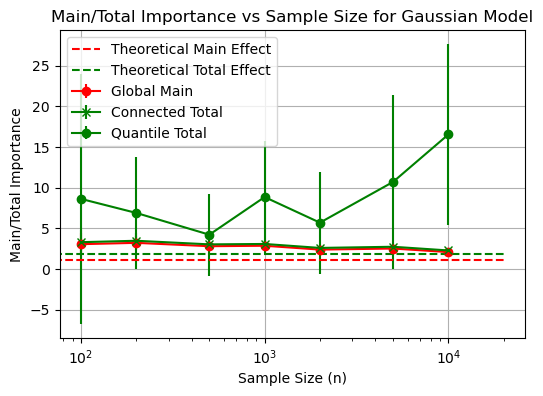

In [11]:
plt.figure(figsize=(6, 4))
# use line plot with errors on the line
plt.errorbar(n_vec, mean_global_g, yerr=std_global_g, label='Global Main', marker='o', color='r')
plt.errorbar(n_vec, mean_connected_g, yerr=std_connected_g, label='Connected Total', marker='x', color='g')
plt.errorbar(n_vec, mean_quantile_g, yerr=std_quantile_g, label='Quantile Total', marker='o', color='g')
# main effect theoretical horizontal line at 1 + (rho ** 2) / 2
plt.hlines(y=1 + (rho ** 2) / 2, xmin=0, xmax=2*np.max(n_vec), color='r', linestyle='--', label='Theoretical Main Effect')
# total effect theoretical horizontal line at 2 - (rho ** 2) / 2
plt.hlines(y=2 - (rho ** 2) / 2, xmin=0, xmax=2*np.max(n_vec), color='g', linestyle='--', label='Theoretical Total Effect')
plt.xscale('log')
plt.xlabel('Sample Size (n)')
plt.ylabel('Main/Total Importance')
plt.title('Main/Total Importance vs Sample Size for Gaussian Model')
plt.legend()
plt.grid()
plt.show()